# EMNIST Digits — VAE CPU/GPU Benchmark
## Same model, same data, same training workload

### Research question

\[
\boxed{\text{VAE training on CPU vs the same VAE training on GPU}}
\]

This notebook is for a **hardware/platform comparison**, not a comparison
between VAE and DCGAN.

### Dataset

The complete standard EMNIST Digits split is used:

- **240,000 training images** for VAE training;
- **40,000 test images** for reconstruction/inference evaluation.

CPU and GPU runs use the exact same images and the same fixed image order.

### Fair-comparison controls

Both runs use the same:

- VAE architecture;
- batch size;
- number of epochs;
- latent dimension;
- Adam learning rate;
- random seed;
- loss function;
- training images;
- test images;
- evaluation procedure.

The full image tensors are moved to the selected execution device **before**
timing and carbon tracking. Therefore host-to-GPU dataset transfer is excluded
from the measured training workload, matching the compute-focused methodology
used in the clustering experiments.

### Metrics

- VAE training time;
- training throughput;
- reconstruction/inference time;
- reconstruction throughput;
- BCE + KL training loss;
- test ELBO-style loss;
- sample-generation time;
- peak memory;
- CodeCarbon energy;
- CodeCarbon CO₂e.

### Carbon methodology

The clean full training run is timed with CodeCarbon **off**.

Energy/carbon are measured separately in 3 steady-state training blocks, each
lasting at least 60 seconds. The result is normalized per 1,000 training
images and then scaled to the complete configured training workload:

\[
N_{\text{training images processed}}
=
N_{\text{train}}\times\text{epochs}
\]

The scaled full-training energy/CO₂e is therefore an **estimate based on
steady-state measured training blocks**, not a wall-socket measurement.


## 1. Select CPU or GPU

In [1]:
# Change only this line for the two final experiments.
DEVICE = "cpu"          # "cpu" or "cuda"

DEVICE = DEVICE.lower().strip()

if DEVICE not in {"cpu", "cuda"}:
    raise ValueError("DEVICE must be 'cpu' or 'cuda'.")

print("Selected device:", DEVICE.upper())


Selected device: CPU


## 2. Imports and environment

In [2]:
import os
import gc
import sys
import time
import random
import threading
import subprocess
import importlib.util
from pathlib import Path

def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name or module_name,
        ])

ensure_package("codecarbon")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torchvision.utils import make_grid

from codecarbon import EmissionsTracker

device = torch.device(DEVICE)

if device.type == "cuda":
    if not torch.cuda.is_available():
        raise RuntimeError(
            "DEVICE='cuda' but CUDA is not available. "
            "Enable a Kaggle GPU accelerator."
        )
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    print("CPU mode")
    print("Logical CPU cores:", os.cpu_count())

print("PyTorch:", torch.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 74.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


CPU mode
Logical CPU cores: 4
PyTorch: 2.10.0+cpu


## 3. Experimental configuration

In [3]:
SEED = 42

BATCH_SIZE = 256
EPOCHS = 5
LATENT_DIM = 32
LEARNING_RATE = 1e-3

# Evaluation / generation.
INFERENCE_BATCH_SIZE = 512
GENERATION_SAMPLES = 10_000
DISPLAY_SAMPLES = 64

# Energy benchmark.
CARBON_MEASURE_SECS = 1
ENERGY_BLOCKS = 3
ENERGY_MIN_DURATION_S = 60.0
ENERGY_COOLDOWN_S = 5.0

# Memory profiling.
MEMORY_PROFILE_STEPS = 30

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print({
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "latent_dim": LATENT_DIM,
    "learning_rate": LEARNING_RATE,
    "energy_blocks": ENERGY_BLOCKS,
    "energy_min_duration_s": ENERGY_MIN_DURATION_S,
})


{'batch_size': 256, 'epochs': 5, 'latent_dim': 32, 'learning_rate': 0.001, 'energy_blocks': 3, 'energy_min_duration_s': 60.0}


## 4. Load full EMNIST Digits train/test tensors

EMNIST orientation is corrected by transposing the last two image dimensions.

VAE inputs remain in \([0,1]\) because the decoder uses a sigmoid output and
binary cross-entropy reconstruction loss.


In [4]:
train_ds = datasets.EMNIST(
    "./data",
    split="digits",
    train=True,
    download=True,
)

test_ds = datasets.EMNIST(
    "./data",
    split="digits",
    train=False,
    download=True,
)

assert len(train_ds) == 240_000
assert len(test_ds) == 40_000

def prepare_images(raw):
    x = (
        raw
        .float()
        .transpose(1, 2)
        .unsqueeze(1)
        / 255.0
    )
    return x.contiguous()

X_train_cpu = prepare_images(train_ds.data)
X_test_cpu = prepare_images(test_ds.data)

# One fixed shuffled order, identical for CPU and GPU experiments.
rng = np.random.RandomState(SEED)
perm = torch.from_numpy(
    rng.permutation(len(X_train_cpu)).astype(np.int64)
)
X_train_cpu = X_train_cpu[perm].contiguous()

print("Train tensor:", tuple(X_train_cpu.shape))
print("Test tensor :", tuple(X_test_cpu.shape))
print("Train tensor size:", round(X_train_cpu.nbytes / (1024**2), 1), "MB")

# Move the complete workload to the selected device before benchmark timing.
X_train = X_train_cpu.to(device)
X_test = X_test_cpu.to(device)

if device.type == "cuda":
    torch.cuda.synchronize()

print("Execution tensor device:", X_train.device)


100%|██████████| 562M/562M [00:02<00:00, 244MB/s]


Train tensor: (240000, 1, 28, 28)
Test tensor : (40000, 1, 28, 28)
Train tensor size: 717.8 MB
Execution tensor device: cpu


## 5. VAE model

In [5]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(inplace=True),
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                64, 32, kernel_size=4, stride=2, padding=1
            ),                                                     # 7 -> 14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(
                32, 1, kernel_size=4, stride=2, padding=1
            ),                                                     # 14 -> 28
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 64, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar):
    bce = F.binary_cross_entropy(
        recon,
        x,
        reduction="sum",
    )

    kld = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total = bce + kld

    return total, bce, kld


def make_model(seed=SEED):
    set_seed(seed)
    model = ConvVAE(LATENT_DIM).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )
    return model, optimizer

model, optimizer = make_model()
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))


ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=3136, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=32, bias=True)
  (fc_decode): Linear(in_features=32, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)
Trainable parameters: 370945


## 6. Training helpers

In [6]:
def sync_device():
    if device.type == "cuda":
        torch.cuda.synchronize()


def train_one_epoch(model, optimizer):
    model.train()

    total_loss = 0.0
    total_bce = 0.0
    total_kld = 0.0

    for start in range(0, len(X_train), BATCH_SIZE):
        batch = X_train[start:start + BATCH_SIZE]

        optimizer.zero_grad(set_to_none=True)

        recon, mu, logvar = model(batch)
        loss, bce, kld = vae_loss(
            recon,
            batch,
            mu,
            logvar,
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    n = len(X_train)

    return {
        "loss_per_image": total_loss / n,
        "bce_per_image": total_bce / n,
        "kld_per_image": total_kld / n,
    }


@torch.no_grad()
def evaluate_vae(model):
    model.eval()

    total_loss = 0.0
    total_bce = 0.0
    total_kld = 0.0

    sync_device()
    t0 = time.perf_counter()

    for start in range(0, len(X_test), INFERENCE_BATCH_SIZE):
        batch = X_test[start:start + INFERENCE_BATCH_SIZE]

        recon, mu, logvar = model(batch)

        loss, bce, kld = vae_loss(
            recon,
            batch,
            mu,
            logvar,
        )

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    sync_device()
    inference_time = time.perf_counter() - t0

    n = len(X_test)

    return {
        "test_loss_per_image": total_loss / n,
        "test_bce_per_image": total_bce / n,
        "test_kld_per_image": total_kld / n,
        "inference_time_s": inference_time,
        "inference_throughput_images_s": n / inference_time,
    }


## 7. Unmeasured warm-up

In [7]:
warm_model, warm_optimizer = make_model(SEED + 999)

batch = X_train[:BATCH_SIZE]

warm_optimizer.zero_grad(set_to_none=True)
recon, mu, logvar = warm_model(batch)
warm_loss, _, _ = vae_loss(recon, batch, mu, logvar)
warm_loss.backward()
warm_optimizer.step()

sync_device()

del warm_model, warm_optimizer, recon, mu, logvar, warm_loss
gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

print("Warm-up complete.")


Warm-up complete.


## 8. Clean full VAE training benchmark

CodeCarbon is **off** during this run. The reported training time therefore
measures the configured VAE training workload without CodeCarbon monitoring
overhead.


In [8]:
model, optimizer = make_model(SEED)

history = []

sync_device()
training_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()

    metrics = train_one_epoch(
        model,
        optimizer,
    )

    sync_device()
    epoch_time = time.perf_counter() - epoch_start

    row = {
        "epoch": epoch,
        "epoch_time_s": epoch_time,
        **metrics,
    }

    history.append(row)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"time={epoch_time:.2f}s | "
        f"loss/image={metrics['loss_per_image']:.4f} | "
        f"BCE={metrics['bce_per_image']:.4f} | "
        f"KLD={metrics['kld_per_image']:.4f}"
    )

sync_device()
training_time_s = time.perf_counter() - training_start

training_throughput = (
    len(X_train) * EPOCHS
    / training_time_s
)

history_df = pd.DataFrame(history)

print("\nClean training time:", round(training_time_s, 3), "s")
print("Training throughput:", round(training_throughput, 1), "images/s")

display(history_df.round(6))


Epoch 1/5 | time=114.91s | loss/image=167.4566 | BCE=135.8532 | KLD=31.6034
Epoch 2/5 | time=114.15s | loss/image=144.7707 | BCE=113.7591 | KLD=31.0116
Epoch 3/5 | time=116.12s | loss/image=142.3441 | BCE=112.2112 | KLD=30.1330
Epoch 4/5 | time=110.87s | loss/image=141.1030 | BCE=111.3592 | KLD=29.7438
Epoch 5/5 | time=112.36s | loss/image=140.2776 | BCE=110.8379 | KLD=29.4398

Clean training time: 568.422 s
Training throughput: 2111.1 images/s


,epoch,epoch_time_s,loss_per_image,bce_per_image,kld_per_image
0,1,114.913023,167.456557,135.853182,31.603375
1,2,114.154139,144.770742,113.759115,31.011628
2,3,116.115352,142.344147,112.211172,30.132975
3,4,110.872158,141.103014,111.359242,29.743771
4,5,112.364551,140.277650,110.837866,29.439784


## 9. Reconstruction inference and sample-generation timing

In [9]:
test_metrics = evaluate_vae(model)

print(
    "Reconstruction inference time:",
    round(test_metrics["inference_time_s"], 4),
    "s",
)

print(
    "Reconstruction throughput:",
    round(test_metrics["inference_throughput_images_s"], 1),
    "images/s",
)

print(
    "Test loss/image:",
    round(test_metrics["test_loss_per_image"], 4),
)

@torch.no_grad()
def time_generation(model, n_samples):
    model.eval()

    generated = 0

    sync_device()
    t0 = time.perf_counter()

    while generated < n_samples:
        current = min(
            INFERENCE_BATCH_SIZE,
            n_samples - generated,
        )

        z = torch.randn(
            current,
            LATENT_DIM,
            device=device,
        )

        _ = model.decode(z)

        generated += current

    sync_device()
    elapsed = time.perf_counter() - t0

    return elapsed, n_samples / elapsed


generation_time_s, generation_throughput = time_generation(
    model,
    GENERATION_SAMPLES,
)

print(
    f"Generation time ({GENERATION_SAMPLES:,} images):",
    round(generation_time_s, 4),
    "s",
)

print(
    "Generation throughput:",
    round(generation_throughput, 1),
    "images/s",
)


Reconstruction inference time: 7.5633 s
Reconstruction throughput: 5288.7 images/s
Test loss/image: 140.1085
Generation time (10,000 images): 1.1318 s
Generation throughput: 8835.7 images/s


## 10. Separate memory profiling

In [10]:
process = psutil.Process(os.getpid())

class PeakRSS:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.peak = 0
        self.stop_event = threading.Event()

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                self.peak = max(
                    self.peak,
                    process.memory_info().rss,
                )
            except Exception:
                pass
            time.sleep(self.interval)

    def start(self):
        self.peak = process.memory_info().rss
        self.stop_event.clear()
        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        self.thread.join(timeout=2)
        return self.peak / (1024**2)


mem_model, mem_optimizer = make_model(SEED)

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

rss_monitor = PeakRSS()
rss_monitor.start()

for step, start in enumerate(
    range(0, len(X_train), BATCH_SIZE)
):
    if step >= MEMORY_PROFILE_STEPS:
        break

    batch = X_train[start:start + BATCH_SIZE]

    mem_optimizer.zero_grad(set_to_none=True)

    recon, mu, logvar = mem_model(batch)
    loss, _, _ = vae_loss(
        recon,
        batch,
        mu,
        logvar,
    )

    loss.backward()
    mem_optimizer.step()

sync_device()

peak_process_ram_mb = rss_monitor.stop()

if device.type == "cuda":
    peak_gpu_allocated_mb = (
        torch.cuda.max_memory_allocated()
        / (1024**2)
    )
else:
    peak_gpu_allocated_mb = np.nan

print("Peak process RAM:", round(peak_process_ram_mb, 2), "MB")

if device.type == "cuda":
    print(
        "Peak PyTorch GPU allocated memory:",
        round(peak_gpu_allocated_mb, 2),
        "MB",
    )

del mem_model, mem_optimizer
gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()


Peak process RAM: 1608.26 MB


## 11. CodeCarbon steady-state training blocks

Each block uses a **fresh VAE and optimizer** and repeatedly performs complete
training steps for at least 60 seconds.

Energy and CO₂e are reported per 1,000 processed training images. The mean
steady-state measurement is then scaled to the configured full training
workload.


In [11]:
def make_tracker(block):
    try:
        return EmissionsTracker(
            project_name=f"vae_emnist_{device.type}_block_{block}",
            measure_power_secs=CARBON_MEASURE_SECS,
            tracking_mode="process",
            gpu_ids=([0] if device.type == "cuda" else []),
            save_to_file=False,
            save_to_api=False,
            log_level="error",
        )
    except Exception as exc:
        print("CodeCarbon unavailable:", exc)
        return None


energy_rows = []

for block in range(1, ENERGY_BLOCKS + 1):
    energy_model, energy_optimizer = make_model(
        SEED + 100 + block
    )

    gc.collect()

    if device.type == "cuda":
        torch.cuda.empty_cache()

    tracker = make_tracker(block)

    if tracker is None:
        break

    tracker.start()
    sync_device()

    block_start = time.perf_counter()
    samples_processed = 0
    steps = 0
    start = 0

    try:
        while True:
            if start >= len(X_train):
                start = 0

            batch = X_train[
                start:start + BATCH_SIZE
            ]

            if len(batch) == 0:
                start = 0
                continue

            energy_optimizer.zero_grad(set_to_none=True)

            recon, mu, logvar = energy_model(batch)

            loss, _, _ = vae_loss(
                recon,
                batch,
                mu,
                logvar,
            )

            loss.backward()
            energy_optimizer.step()

            samples_processed += len(batch)
            steps += 1
            start += BATCH_SIZE

            sync_device()

            if (
                time.perf_counter()
                - block_start
            ) >= ENERGY_MIN_DURATION_S:
                break

    finally:
        sync_device()
        duration_s = time.perf_counter() - block_start
        emissions_kg = tracker.stop()

    data = getattr(
        tracker,
        "final_emissions_data",
        None,
    )

    def attr(name):
        if data is None:
            return np.nan
        value = getattr(data, name, np.nan)
        return np.nan if value is None else value

    total_energy_kwh = attr("energy_consumed")
    cpu_energy_kwh = attr("cpu_energy")
    gpu_energy_kwh = attr("gpu_energy")
    ram_energy_kwh = attr("ram_energy")

    thousands = samples_processed / 1000.0

    row = {
        "block": block,
        "device": device.type,
        "steps": steps,
        "samples_processed": samples_processed,
        "duration_s": duration_s,
        "energy_block_kwh": total_energy_kwh,
        "co2_block_kg": emissions_kg,
        "energy_wh_per_1000_images": (
            total_energy_kwh * 1000.0 / thousands
        ),
        "co2_g_per_1000_images": (
            emissions_kg * 1000.0 / thousands
        ),
        "cpu_energy_kwh_per_1000_images": (
            cpu_energy_kwh / thousands
        ),
        "gpu_energy_kwh_per_1000_images": (
            gpu_energy_kwh / thousands
        ),
        "ram_energy_kwh_per_1000_images": (
            ram_energy_kwh / thousands
        ),
        "carbon_country": (
            getattr(data, "country_name", None)
            if data is not None else None
        ),
    }

    energy_rows.append(row)

    print(
        f"Block {block}: "
        f"{samples_processed:,} images, "
        f"{duration_s:.1f}s, "
        f"{row['energy_wh_per_1000_images']:.6f} Wh/1k images, "
        f"{row['co2_g_per_1000_images']:.6f} g CO2e/1k images"
    )

    del energy_model, energy_optimizer
    gc.collect()

    if device.type == "cuda":
        torch.cuda.empty_cache()

    if block < ENERGY_BLOCKS:
        time.sleep(ENERGY_COOLDOWN_S)


energy_df = pd.DataFrame(energy_rows)

display(energy_df.round(8))

training_images_total = len(X_train) * EPOCHS

mean_wh_per_1k = energy_df[
    "energy_wh_per_1000_images"
].mean()

std_wh_per_1k = energy_df[
    "energy_wh_per_1000_images"
].std()

mean_co2_g_per_1k = energy_df[
    "co2_g_per_1000_images"
].mean()

std_co2_g_per_1k = energy_df[
    "co2_g_per_1000_images"
].std()

estimated_training_energy_wh = (
    mean_wh_per_1k
    * training_images_total
    / 1000.0
)

estimated_training_co2_g = (
    mean_co2_g_per_1k
    * training_images_total
    / 1000.0
)

print(
    "Estimated full-training energy:",
    round(estimated_training_energy_wh, 6),
    "Wh",
)

print(
    "Estimated full-training CO2e:",
    round(estimated_training_co2_g, 6),
    "g",
)


[codecarbon WARNING @ 16:05:03] Multiple instances of codecarbon are allowed to run at the same time.


Block 1: 120,832 images, 60.1s, 0.002464 Wh/1k images, 0.000342 g CO2e/1k images
Block 2: 123,136 images, 60.1s, 0.002423 Wh/1k images, 0.000336 g CO2e/1k images
Block 3: 130,048 images, 60.0s, 0.002301 Wh/1k images, 0.000319 g CO2e/1k images


,block,device,steps,samples_processed,duration_s,energy_block_kwh,co2_block_kg,energy_wh_per_1000_images,co2_g_per_1000_images,cpu_energy_kwh_per_1000_images,gpu_energy_kwh_per_1000_images,ram_energy_kwh_per_1000_images,carbon_country
0,1,cpu,472,120832,60.065653,0.000298,0.000041,0.002464,0.000342,0.000001,0.0,0.000001,United States
1,2,cpu,481,123136,60.092377,0.000298,0.000041,0.002423,0.000336,0.000001,0.0,0.000001,United States
2,3,cpu,508,130048,60.043160,0.000299,0.000042,0.002301,0.000319,0.000001,0.0,0.000001,United States


Estimated full-training energy: 2.875111 Wh
Estimated full-training CO2e: 0.398921 g


## 12. Generated sample visualization

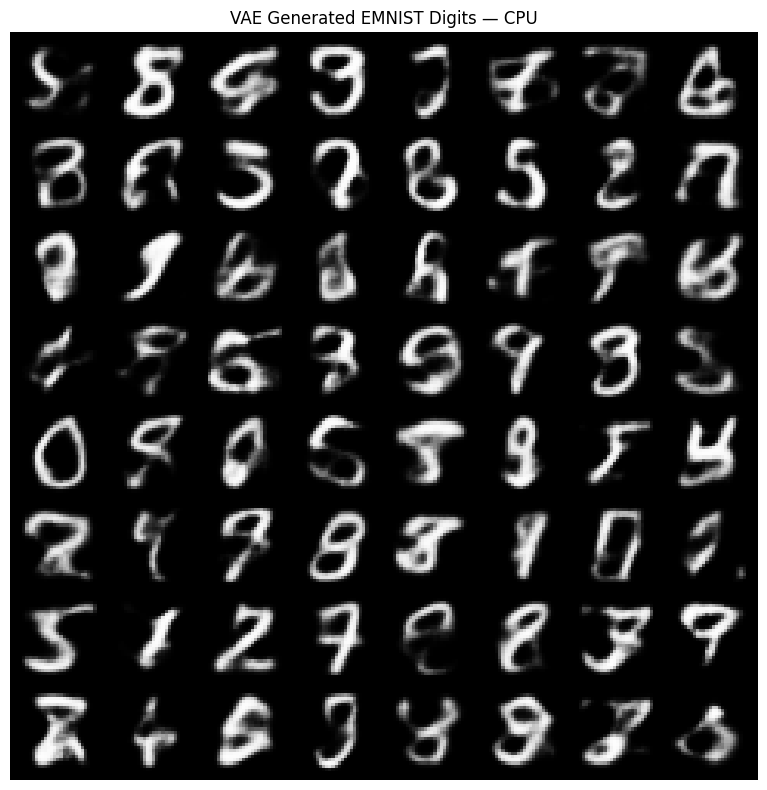

In [12]:
model.eval()

with torch.no_grad():
    z = torch.randn(
        DISPLAY_SAMPLES,
        LATENT_DIM,
        device=device,
    )

    samples = model.decode(z).cpu()

grid = make_grid(
    samples,
    nrow=8,
    padding=2,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray",
)

ax.axis("off")
ax.set_title(f"VAE Generated EMNIST Digits — {DEVICE.upper()}")

fig.tight_layout()
fig.savefig(
    f"vae_emnist_{device.type}_samples.png",
    dpi=160,
)

plt.show()


## 13. Final summary and outputs

In [13]:
summary_df = pd.DataFrame([{
    "model": "VAE",
    "device": device.type,
    "train_images": len(X_train),
    "test_images": len(X_test),
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "latent_dim": LATENT_DIM,
    "training_time_s": training_time_s,
    "training_throughput_images_s": training_throughput,
    "final_train_loss_per_image": history_df["loss_per_image"].iloc[-1],
    "test_loss_per_image": test_metrics["test_loss_per_image"],
    "reconstruction_inference_time_s": test_metrics["inference_time_s"],
    "reconstruction_throughput_images_s": test_metrics[
        "inference_throughput_images_s"
    ],
    "generation_samples": GENERATION_SAMPLES,
    "generation_time_s": generation_time_s,
    "generation_throughput_images_s": generation_throughput,
    "peak_process_ram_mb": peak_process_ram_mb,
    "peak_gpu_allocated_mb": peak_gpu_allocated_mb,
    "energy_wh_per_1000_images_mean": mean_wh_per_1k,
    "energy_wh_per_1000_images_std": std_wh_per_1k,
    "co2_g_per_1000_images_mean": mean_co2_g_per_1k,
    "co2_g_per_1000_images_std": std_co2_g_per_1k,
    "estimated_full_training_energy_wh": estimated_training_energy_wh,
    "estimated_full_training_co2_g": estimated_training_co2_g,
}])

display(summary_df.round(8))

output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

history_df.to_csv(
    output_dir / f"vae_emnist_{device.type}_history.csv",
    index=False,
)

energy_df.to_csv(
    output_dir / f"vae_emnist_{device.type}_codecarbon.csv",
    index=False,
)

summary_df.to_csv(
    output_dir / f"vae_emnist_{device.type}_summary.csv",
    index=False,
)

print("Saved outputs to:", output_dir)


,model,device,train_images,test_images,epochs,batch_size,latent_dim,training_time_s,training_throughput_images_s,final_train_loss_per_image,...,generation_time_s,generation_throughput_images_s,peak_process_ram_mb,peak_gpu_allocated_mb,energy_wh_per_1000_images_mean,energy_wh_per_1000_images_std,co2_g_per_1000_images_mean,co2_g_per_1000_images_std,estimated_full_training_energy_wh,estimated_full_training_co2_g
0,VAE,cpu,240000,40000,5,256,32,568.421641,2111.108926,140.27765,...,1.131769,8835.728668,1608.261719,NaN,0.002396,0.000084,0.000332,0.000012,2.87511,0.398921


Saved outputs to: /kaggle/working


# Reporting rule

Compare only:

\[
\boxed{\text{VAE CPU vs VAE GPU}}
\]

Do not use the raw VAE training time to claim that VAE is faster/slower or
greener than DCGAN, because they are different model architectures and
training workloads.

For the hardware comparison, report:

- CPU/GPU training speedup;
- CPU/GPU reconstruction-inference speedup;
- CPU/GPU generation speedup;
- energy per 1,000 training images;
- estimated full-training energy;
- estimated full-training CO₂e;
- peak memory;
- final VAE loss.
